<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">🌳 Ensamble avanzado: bagging, boosting, voting y stacking</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 3 — Profundización en modelos de ensamble más allá de Random Forest y XGBoost sobre Iris</p>
</div>

En <code>../1_ML_implementation.ipynb</code> se presentaron Random Forest y XGBoost sobre el dataset Iris. Ese dataset, sin embargo, es demasiado simple para el propósito de este notebook: con solo 4 variables y 3 clases casi perfectamente separadas, un único árbol de decisión sin podar ya se acerca al 100% de accuracy. Esto oculta justamente lo que aquí interesa mostrar: cuánto mejora un ensamble sobre un modelo individual, y qué diferencias reales existen entre bagging y boosting.

Por eso este notebook usa el dataset **Breast Cancer Wisconsin** (<code>sklearn.datasets.load_breast_cancer</code>): 569 muestras, 30 variables numéricas derivadas de imágenes digitalizadas de biopsias, y una variable objetivo binaria (maligno / benigno). Tiene suficiente ruido, correlación entre variables y dificultad real como para que la reducción de varianza del bagging, la reducción de sesgo del boosting, y el aporte de combinar modelos con voting o stacking, se noten en las métricas. Al igual que Iris, viene incluido en <code>scikit-learn</code> y no requiere conexión a internet ni archivos externos.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#dataset">El dataset: Breast Cancer Wisconsin</a></li>
<li><a href="#bagging">Bagging: reducción de varianza</a></li>
<li><a href="#random-forest">Random Forest e importancia de características</a></li>
<li><a href="#boosting">Boosting: AdaBoost, Gradient Boosting, XGBoost y LightGBM</a></li>
<li><a href="#voting">Voting Classifier: votación dura y suave</a></li>
<li><a href="#stacking">Stacking Classifier</a></li>
<li><a href="#comparativa">Tabla comparativa final</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="dataset"></a>

## <span style="color:#F97066;">El dataset: Breast Cancer Wisconsin</span>

<span style="color:#F97066;">1.</span> Carga y exploración inicial

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
import pandas as pd

# 1. Cargar datos
datos = load_breast_cancer()
X = pd.DataFrame(datos.data, columns=datos.feature_names)
y = pd.Series(datos.target, name="diagnostico")

# 2. Exploración básica
print(f"Dimensiones: {X.shape}")
print(f"\nDistribución de clases (0=maligno, 1=benigno):\n{y.value_counts()}")

# 3. División en entrenamiento y prueba (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Esquema de validación cruzada reutilizado en todo el notebook
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nEntrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras")

Dimensiones: (569, 30)

Distribución de clases (0=maligno, 1=benigno):
diagnostico
1    357
0    212
Name: count, dtype: int64

Entrenamiento: 455 muestras | Prueba: 114 muestras


<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Todas las comparaciones de este notebook usan la misma partición de entrenamiento/prueba y el mismo esquema de validación cruzada (<code>cv</code>) definidos arriba, para que las diferencias observadas entre modelos reflejen el algoritmo y no un azar en la partición de los datos.
</div>

<a id="bagging"></a>

## <span style="color:#F97066;">Bagging: reducción de varianza</span>

El bagging (*bootstrap aggregating*) entrena varias copias del mismo modelo base sobre distintas muestras bootstrap del conjunto de entrenamiento, y combina sus predicciones por votación. Un único árbol de decisión sin restricciones tiende a sobreajustar y a variar mucho según la muestra de entrenamiento; el bagging ataca justamente esa varianza. A continuación se compara, mediante validación cruzada, un árbol de decisión individual contra un <code>BaggingClassifier</code> de 50 árboles.

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_val_score

# 1. Modelo base: un único árbol de decisión sin restricciones
arbol_unico = DecisionTreeClassifier(random_state=42)

# 2. Ensamble de bagging: 50 árboles entrenados sobre muestras bootstrap
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
)

# 3. Validación cruzada para ambos modelos sobre el mismo conjunto de entrenamiento
scores_arbol = cross_val_score(arbol_unico, X_train, y_train, cv=cv, scoring="accuracy")
scores_bagging = cross_val_score(bagging, X_train, y_train, cv=cv, scoring="accuracy")

print("Árbol de decisión individual:")
print(f"  Accuracy promedio: {scores_arbol.mean():.4f}  |  Desviación estándar: {scores_arbol.std():.4f}")
print("\nBagging (50 árboles):")
print(f"  Accuracy promedio: {scores_bagging.mean():.4f}  |  Desviación estándar: {scores_bagging.std():.4f}")

Árbol de decisión individual:
  Accuracy promedio: 0.9165  |  Desviación estándar: 0.0179

Bagging (50 árboles):
  Accuracy promedio: 0.9516  |  Desviación estándar: 0.0204


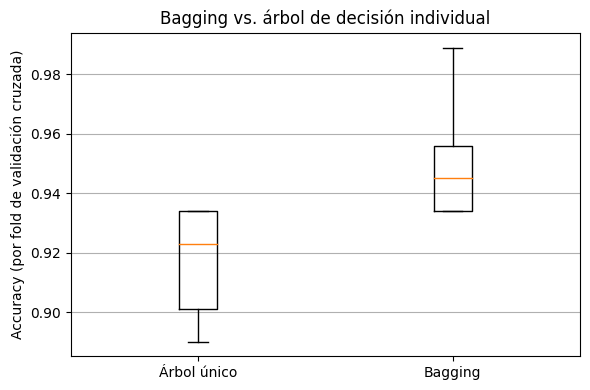

In [3]:
import matplotlib.pyplot as plt

# 4. Visualización de la dispersión de los puntajes por fold
plt.figure(figsize=(6, 4))
plt.boxplot([scores_arbol, scores_bagging], labels=["Árbol único", "Bagging"])
plt.ylabel("Accuracy (por fold de validación cruzada)")
plt.title("Bagging vs. árbol de decisión individual")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
En esta ejecución, el bagging elevó notoriamente la accuracy promedio frente al árbol individual (de aproximadamente 0.92 a 0.95): al promediar el voto de 50 árboles entrenados sobre distintas muestras bootstrap, el ensamble deja de depender de las particiones específicas que un único árbol memoriza. Con apenas 5 folds, la desviación estándar entre folds es en sí misma una estimación ruidosa, por lo que no siempre baja de forma limpia de un modelo a otro; lo que sí es consistente es la mejora en el desempeño promedio.
</div>

<a id="random-forest"></a>

## <span style="color:#F97066;">Random Forest e importancia de características</span>

Random Forest extiende el bagging agregando una segunda fuente de aleatoriedad: en cada partición de cada árbol solo se considera un subconjunto aleatorio de variables. Esto descorrelaciona aún más los árboles del ensamble. Con las 30 variables reales de este dataset (en contraste con las 4 de Iris), la importancia de características resulta mucho más informativa para entender qué mide realmente el modelo.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Crear y entrenar el modelo (oob_score permite estimar el error sin usar el conjunto de prueba)
random_forest = RandomForestClassifier(
    n_estimators=300,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
random_forest.fit(X_train, y_train)

# 2. Puntaje "out-of-bag": estimación de generalización usando las muestras no vistas por cada árbol
print(f"Puntaje OOB (out-of-bag): {random_forest.oob_score_:.4f}")

# 3. Evaluación sobre el conjunto de prueba
y_pred_rf = random_forest.predict(X_test)
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred_rf, target_names=["maligno", "benigno"]))

Puntaje OOB (out-of-bag): 0.9560

Matriz de Confusión:
 [[39  3]
 [ 3 69]]

Reporte de Clasificación:
               precision    recall  f1-score   support

     maligno       0.93      0.93      0.93        42
     benigno       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



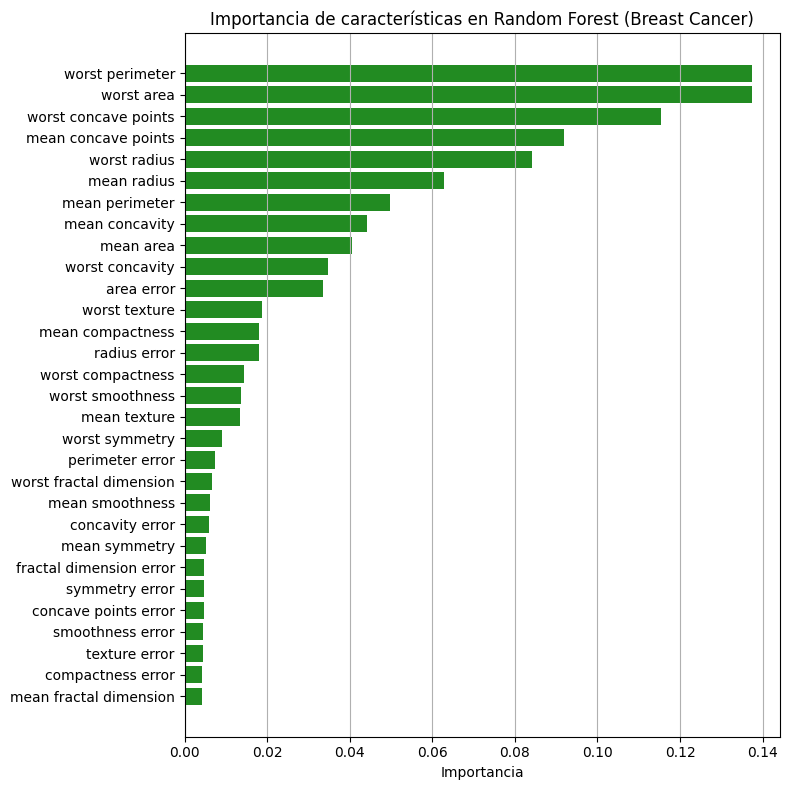

Cinco variables más importantes:
worst perimeter         0.137344
worst area              0.137312
worst concave points    0.115502
mean concave points     0.091774
worst radius            0.084111
dtype: float64


In [5]:
# 4. Importancia de características (30 variables reales, a diferencia de las 4 de Iris)
importancias = pd.Series(random_forest.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 8))
plt.barh(importancias.index, importancias.values, color="forestgreen")
plt.xlabel("Importancia")
plt.title("Importancia de características en Random Forest (Breast Cancer)")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

print("Cinco variables más importantes:")
print(importancias.sort_values(ascending=False).head(5))

<a id="boosting"></a>

## <span style="color:#F97066;">Boosting: AdaBoost, Gradient Boosting, XGBoost y LightGBM</span>

A diferencia del bagging, el boosting entrena los modelos base de forma secuencial: cada nuevo modelo se enfoca en corregir los errores del anterior. Esto reduce el sesgo del ensamble, a costa de ser más sensible al sobreajuste y a los hiperparámetros. A continuación se entrenan cuatro variantes de boosting, de la más clásica a las más usadas en la práctica actual.

### <span style="color:#F97066;">AdaBoost</span>

In [6]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. Crear y entrenar AdaBoost sobre árboles de decisión muy superficiales ("stumps")
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=200,
    algorithm="SAMME",
    random_state=42,
)
adaboost.fit(X_train, y_train)

# 2. Evaluación sobre el conjunto de prueba
y_pred_ada = adaboost.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}  |  F1-score: {f1_score(y_test, y_pred_ada):.4f}")

Accuracy: 0.9649  |  F1-score: 0.9730


### <span style="color:#F97066;">Gradient Boosting</span>

In [7]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Crear y entrenar Gradient Boosting
gradient_boosting = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)
gradient_boosting.fit(X_train, y_train)

# 2. Evaluación sobre el conjunto de prueba
y_pred_gb = gradient_boosting.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}  |  F1-score: {f1_score(y_test, y_pred_gb):.4f}")

Accuracy: 0.9561  |  F1-score: 0.9660


### <span style="color:#F97066;">XGBoost</span>

XGBoost ya se presentó en <code>../1_ML_implementation.ipynb</code> sobre Iris. Aquí se entrena sobre un problema binario más exigente, donde las diferencias de desempeño frente a las demás variantes de boosting son más visibles.

In [8]:
import xgboost as xgb

# 1. Crear y entrenar XGBoost
xgboost_modelo = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=42,
)
xgboost_modelo.fit(X_train, y_train)

# 2. Evaluación sobre el conjunto de prueba
y_pred_xgb = xgboost_modelo.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}  |  F1-score: {f1_score(y_test, y_pred_xgb):.4f}")

Accuracy: 0.9474  |  F1-score: 0.9589


### <span style="color:#F97066;">LightGBM</span>

LightGBM es otra implementación de gradient boosting, orientada a conjuntos de datos grandes: en lugar de crecer los árboles nivel por nivel, los crece hoja por hoja (*leaf-wise*), lo que suele ser más rápido y, en datasets con muchas variables, igual de preciso.

In [9]:
import lightgbm as lgb

# 1. Crear y entrenar LightGBM
lightgbm_modelo = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
)
lightgbm_modelo.fit(X_train, y_train)

# 2. Evaluación sobre el conjunto de prueba
y_pred_lgbm = lightgbm_modelo.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}  |  F1-score: {f1_score(y_test, y_pred_lgbm):.4f}")

Accuracy: 0.9561  |  F1-score: 0.9660


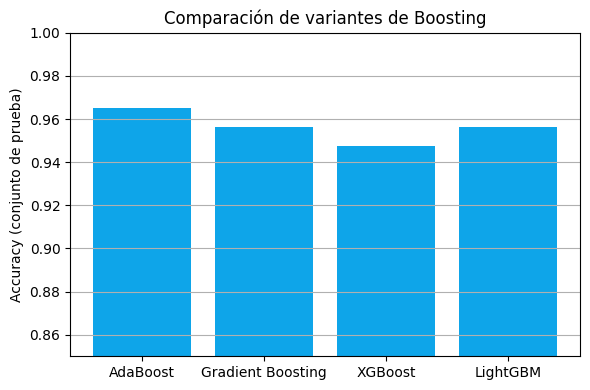

In [10]:
# 3. Comparación visual de las cuatro variantes de boosting sobre el conjunto de prueba
boosting_resultados = pd.DataFrame({
    "modelo": ["AdaBoost", "Gradient Boosting", "XGBoost", "LightGBM"],
    "accuracy": [
        accuracy_score(y_test, y_pred_ada),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm),
    ],
})

plt.figure(figsize=(6, 4))
plt.bar(boosting_resultados["modelo"], boosting_resultados["accuracy"], color="#0EA5E9")
plt.ylabel("Accuracy (conjunto de prueba)")
plt.title("Comparación de variantes de Boosting")
plt.ylim(0.85, 1.0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

<a id="voting"></a>

## <span style="color:#F97066;">Voting Classifier: votación dura y suave</span>

A diferencia de bagging y boosting, un <code>VotingClassifier</code> no combina copias del mismo modelo base, sino modelos de naturaleza distinta: aquí se combinan una Regresión Logística, una Máquina de Vectores de Soporte (SVM) y un Árbol de Decisión. La **votación dura** (hard) usa la clase más votada entre los modelos; la **votación suave** (soft) promedia las probabilidades predichas por cada modelo. En teoría, la votación suave suele aprovechar mejor la confianza relativa de cada modelo cuando sus probabilidades están razonablemente calibradas, pero esto no está garantizado: con pocos modelos base, o si alguno está mal calibrado, la votación dura puede terminar siendo competitiva o incluso mejor, como se observa a continuación.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
La Regresión Logística y la SVM son sensibles a la escala de las variables, por lo que cada una se envuelve en un <code>Pipeline</code> con <code>StandardScaler</code>. El Árbol de Decisión no lo necesita, ya que sus particiones son invariantes a transformaciones monótonas de cada variable.
</div>

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier

# 1. Modelos base, con escalado para los sensibles a la magnitud de las variables
modelo_lr = Pipeline([("escalador", StandardScaler()), ("clf", LogisticRegression(max_iter=5000, random_state=42))])
modelo_svm = Pipeline([("escalador", StandardScaler()), ("clf", SVC(probability=True, random_state=42))])
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)

estimadores_base = [("reg_logistica", modelo_lr), ("svm", modelo_svm), ("arbol", modelo_arbol)]

# 2. Voting con votación dura (clase más votada)
voting_duro = VotingClassifier(estimators=estimadores_base, voting="hard")
voting_duro.fit(X_train, y_train)
y_pred_voting_duro = voting_duro.predict(X_test)

# 3. Voting con votación suave (promedio de probabilidades)
voting_suave = VotingClassifier(estimators=estimadores_base, voting="soft")
voting_suave.fit(X_train, y_train)
y_pred_voting_suave = voting_suave.predict(X_test)

print("Voting (votación dura):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_voting_duro):.4f}  |  F1-score: {f1_score(y_test, y_pred_voting_duro):.4f}")
print("\nVoting (votación suave):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_voting_suave):.4f}  |  F1-score: {f1_score(y_test, y_pred_voting_suave):.4f}")

Voting (votación dura):
  Accuracy: 0.9825  |  F1-score: 0.9861

Voting (votación suave):
  Accuracy: 0.9737  |  F1-score: 0.9793


<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
En esta ejecución, la votación dura superó ligeramente a la votación suave. Esto es posible: el promedio de probabilidades de la votación suave puede verse arrastrado por un modelo mal calibrado (aquí, la SVM sin ajuste fino), mientras que la votación dura solo depende de la clase predicha por cada modelo, sin importar qué tan segura estaba la predicción.
</div>

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Se sugiere reemplazar alguno de los tres modelos base (por ejemplo, la SVM por un <code>KNeighborsClassifier</code>) y volver a comparar la votación dura contra la suave. ¿Cambia cuál de las dos resulta mejor? ¿Por qué podría depender de qué tan bien calibradas estén las probabilidades de cada modelo base?

<a id="stacking"></a>

## <span style="color:#F97066;">Stacking Classifier</span>

El stacking también combina modelos de distinta naturaleza, pero en lugar de votar o promediar sus salidas de forma fija, entrena un **meta-modelo** que aprende cómo combinar las predicciones de los modelos base. Aquí se usan los mismos tres modelos base de la sección anterior (Regresión Logística, SVM y Árbol de Decisión), y una Regresión Logística como meta-modelo combinador.

In [12]:
from sklearn.ensemble import StackingClassifier

# 1. Mismos modelos base, combinados ahora por un meta-modelo entrenado con validación cruzada interna
stacking = StackingClassifier(
    estimators=estimadores_base,
    final_estimator=LogisticRegression(max_iter=5000, random_state=42),
    cv=5,
)
stacking.fit(X_train, y_train)

# 2. Evaluación sobre el conjunto de prueba
y_pred_stacking = stacking.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}  |  F1-score: {f1_score(y_test, y_pred_stacking):.4f}")

Accuracy: 0.9737  |  F1-score: 0.9790


<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
El parámetro <code>cv</code> de <code>StackingClassifier</code> controla cómo se generan las predicciones de los modelos base que alimentan al meta-modelo: se usa validación cruzada interna (en lugar de las predicciones sobre el propio conjunto de entrenamiento) para evitar que el meta-modelo aprenda a confiar ciegamente en modelos base que ya vieron esos datos durante su propio entrenamiento.
</div>

<a id="comparativa"></a>

## <span style="color:#F97066;">Tabla comparativa final</span>

Para cerrar, se valida con validación cruzada (<code>cross_validate</code>, sobre el mismo conjunto de entrenamiento y el mismo esquema <code>cv</code> usados en todo el notebook) cada uno de los modelos vistos, reportando accuracy, F1-score y ROC-AUC (adecuado aquí por tratarse de un problema binario). Para el Voting Classifier se usa la variante de votación suave, ya que es la única que expone las probabilidades necesarias para calcular ROC-AUC.

In [13]:
from sklearn.model_selection import cross_validate

# 1. Modelos a comparar
modelos_comparar = {
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Bagging": bagging,
    "Random Forest": random_forest,
    "AdaBoost": adaboost,
    "Gradient Boosting": gradient_boosting,
    "XGBoost": xgboost_modelo,
    "LightGBM": lightgbm_modelo,
    "Voting (soft)": voting_suave,
    "Stacking": stacking,
}

# 2. Métricas de interés para un problema de clasificación binaria
metricas = ["accuracy", "f1", "roc_auc"]

# 3. Validación cruzada de cada modelo
filas = []
for nombre, modelo in modelos_comparar.items():
    resultado = cross_validate(modelo, X_train, y_train, cv=cv, scoring=metricas, n_jobs=-1)
    filas.append({
        "Modelo": nombre,
        "Accuracy": resultado["test_accuracy"].mean(),
        "F1-score": resultado["test_f1"].mean(),
        "ROC-AUC": resultado["test_roc_auc"].mean(),
    })

tabla_comparativa = pd.DataFrame(filas).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
tabla_comparativa

,Modelo,Accuracy,F1-score,ROC-AUC
0,AdaBoost,0.978022,0.982608,0.995975
1,Stacking,0.978022,0.982516,0.994943
2,Voting (soft),0.964835,0.972061,0.993705
3,LightGBM,0.969231,0.975528,0.993292
4,XGBoost,0.971429,0.977236,0.992570
5,Gradient Boosting,0.953846,0.963228,0.991331
6,Random Forest,0.964835,0.971765,0.990402
7,Bagging,0.951648,0.961100,0.989112
8,Árbol de Decisión,0.916484,0.931901,0.917905


In [14]:
from IPython.display import HTML

# 4. Tabla estilizada a partir de los resultados anteriores
filas_html = ""
for i, fila in tabla_comparativa.iterrows():
    fondo = "background:rgba(14,165,233,0.07);" if i % 2 == 0 else ""
    filas_html += (
        f'<tr style="{fondo}">'
        f'<td style="padding:6px 14px;">{fila["Modelo"]}</td>'
        f'<td style="padding:6px 14px;">{fila["Accuracy"]:.4f}</td>'
        f'<td style="padding:6px 14px;">{fila["F1-score"]:.4f}</td>'
        f'<td style="padding:6px 14px;">{fila["ROC-AUC"]:.4f}</td>'
        f'</tr>'
    )

html_tabla = f"""
<div style="border-radius:12px; overflow:hidden; border:1px solid rgba(14,165,233,0.35); margin:16px 0;">
<table style="width:100%; border-collapse:collapse; font-size:0.9em;">
<thead>
<tr style="background:#0EA5E9;">
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Modelo</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">Accuracy</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">F1-score</th>
<th style="text-align:left; padding:8px 14px; color:#ffffff;">ROC-AUC</th>
</tr>
</thead>
<tbody>
{filas_html}
</tbody>
</table>
</div>
"""

HTML(html_tabla)

Modelo,Accuracy,F1-score,ROC-AUC
AdaBoost,0.9780,0.9826,0.9960
Stacking,0.9780,0.9825,0.9949
Voting (soft),0.9648,0.9721,0.9937
LightGBM,0.9692,0.9755,0.9933
XGBoost,0.9714,0.9772,0.9926
Gradient Boosting,0.9538,0.9632,0.9913
Random Forest,0.9648,0.9718,0.9904
Bagging,0.9516,0.9611,0.9891
Árbol de Decisión,0.9165,0.9319,0.9179


---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>

- Bagging: reducción de varianza comparando un árbol de decisión individual contra un <code>BaggingClassifier</code>, mediante validación cruzada.
- Random Forest: importancia de características sobre 30 variables reales, y estimación de generalización con <code>oob_score_</code>.
- Boosting: AdaBoost, Gradient Boosting, XGBoost y LightGBM, entrenados y comparados sobre un problema binario más exigente que Iris.
- Voting Classifier: combinación de Regresión Logística, SVM y Árbol de Decisión, con votación dura y suave.
- Stacking Classifier: los mismos modelos base, combinados por un meta-modelo entrenado con validación cruzada interna.
- Tabla comparativa final de los nueve modelos, con accuracy, F1-score y ROC-AUC.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>../pipelines-evaluacion/1-pipelines-y-evaluacion.ipynb</code> — encapsular estos modelos (incluyendo el escalado usado aquí) en un <code>Pipeline</code> completo, y validar con métricas y estrategias de validación cruzada más allá del <code>cross_validate</code> usado en este notebook.</li>
</ul>
</div>